In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [36]:
!pip install odfpy

In [37]:
import pandas as pd

# Read the Trust_Scores worksheet
df = pd.read_excel(
    "/content/Benchmark data.ods",
    sheet_name="Trust_Scores",
    engine="odf"
)

print(df.head())
print(df.shape)

  TrustCode                                          trustname  n_tpat  \
0       R0A         Manchester University NHS Foundation Trust     400   
1       R0B  South Tyneside and Sunderland NHS Foundation T...     501   
2       R0D   University Hospitals Dorset NHS Foundation Trust     503   
3       R1F                            Isle of Wight NHS Trust     550   
4       R1H                             Barts Health NHS Trust     364   

     meanQ2    ll90Q2    ul90Q2    ll95Q2    ul95Q2    ll99Q2    ul99Q2  ...  \
0  6.750477  6.417296  7.990097  6.266643  8.140751  5.726264  8.681129  ...   
1  8.525410  6.267793  8.139601  6.088499  8.318895  5.445388  8.962006  ...   
2  7.980697  6.476103  7.931291  6.336715  8.070679  5.836746  8.570648  ...   
3  6.131446  6.329290  8.078104  6.161777  8.245617  5.560925  8.846469  ...   
4  6.650712  6.373358  8.034036  6.214287  8.193107  5.643715  8.763679  ...   

   S10_Zfinal   meanS11   ll90S11   ul90S11   ll95S11   ul95S11   ll99S11 

In [38]:
print(df.columns.tolist())

['TrustCode', 'trustname', 'n_tpat', 'meanQ2', 'll90Q2', 'ul90Q2', 'll95Q2', 'ul95Q2', 'll99Q2', 'ul99Q2', 'bandQ2', 'Q2_Zfinal', 'meanQ4', 'll90Q4', 'ul90Q4', 'll95Q4', 'ul95Q4', 'll99Q4', 'ul99Q4', 'bandQ4', 'Q4_Zfinal', 'meanQ5_1', 'll90Q5_1', 'ul90Q5_1', 'll95Q5_1', 'ul95Q5_1', 'll99Q5_1', 'ul99Q5_1', 'bandQ5_1', 'Q5_1_Zfinal', 'meanQ5_2', 'll90Q5_2', 'ul90Q5_2', 'll95Q5_2', 'ul95Q5_2', 'll99Q5_2', 'ul99Q5_2', 'bandQ5_2', 'Q5_2_Zfinal', 'meanQ5_4', 'll90Q5_4', 'ul90Q5_4', 'll95Q5_4', 'ul95Q5_4', 'll99Q5_4', 'ul99Q5_4', 'bandQ5_4', 'Q5_4_Zfinal', 'meanQ7', 'll90Q7', 'ul90Q7', 'll95Q7', 'ul95Q7', 'll99Q7', 'ul99Q7', 'bandQ7', 'Q7_Zfinal', 'meanQ8', 'll90Q8', 'ul90Q8', 'll95Q8', 'ul95Q8', 'll99Q8', 'ul99Q8', 'bandQ8', 'Q8_Zfinal', 'meanQ9', 'll90Q9', 'ul90Q9', 'll95Q9', 'ul95Q9', 'll99Q9', 'ul99Q9', 'bandQ9', 'Q9_Zfinal', 'meanQ10', 'll90Q10', 'ul90Q10', 'll95Q10', 'ul95Q10', 'll99Q10', 'ul99Q10', 'bandQ10', 'Q10_Zfinal', 'meanQ11', 'll90Q11', 'ul90Q11', 'll95Q11', 'ul95Q11', 'll99Q11

In [39]:
df = df.drop(columns=["TrustCode", "trustname"])

In [40]:
df = df.fillna(df.median(numeric_only=True))

In [41]:
target = "meanQ46"

median = df[target].median()

df["Satisfaction"] = (df[target] >= median).astype(int)

/tmp/ipykernel_1732/924358969.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Satisfaction"] = (df[target] >= median).astype(int)


In [42]:
X = df.drop(columns=[target, "Satisfaction"])

y = df["Satisfaction"]

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [45]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_prediction = lr.predict(X_test)

In [46]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_prediction = dt.predict(X_test)

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_prediction = rf.predict(X_test)

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_prediction),
        accuracy_score(y_test, dt_prediction),
        accuracy_score(y_test, rf_prediction)
    ],
    "Precision": [
        precision_score(y_test, lr_prediction),
        precision_score(y_test, dt_prediction),
        precision_score(y_test, rf_prediction)
    ],
    "Recall": [
        recall_score(y_test, lr_prediction),
        recall_score(y_test, dt_prediction),
        recall_score(y_test, rf_prediction)
    ],
    "F1 Score": [
        f1_score(y_test, lr_prediction),
        f1_score(y_test, dt_prediction),
        f1_score(y_test, rf_prediction)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.851852   0.818182  0.818182  0.818182
1        Decision Tree  1.000000   1.000000  1.000000  1.000000
2        Random Forest  0.888889   0.900000  0.818182  0.857143


In [49]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

        Feature  Importance
494  S10_Zfinal    0.069762
386  Q46_Zfinal    0.064006
486     meanS10    0.061276
441     meanS05    0.032515
217     meanQ26    0.025823
477     meanS09    0.022591
440  S04_Zfinal    0.020263
485  S09_Zfinal    0.019284
199     meanQ24    0.017122
432     meanS04    0.016907
422  S02_Zfinal    0.016788
414     meanS02    0.016584
370     meanQ45    0.016549
279  Q33_Zfinal    0.015106
378  Q45_Zfinal    0.015065
298     meanQ36    0.013695
10       meanQ4    0.013296
154     meanQ19    0.013122
449  S05_Zfinal    0.013063
207  Q24_Zfinal    0.012017


In [50]:
import joblib

joblib.dump(rf,"RandomForest_Model.pkl")

['RandomForest_Model.pkl']

In [51]:
model = joblib.load("RandomForest_Model.pkl")

In [52]:
new_patient = X.iloc[[0]]

prediction = model.predict(new_patient)

print(prediction)

[0]


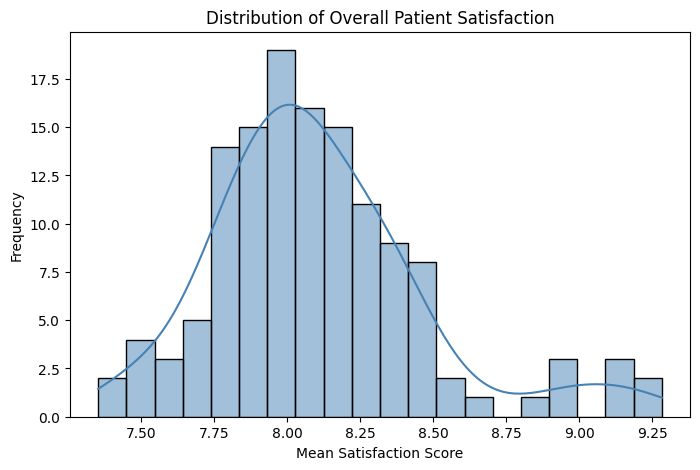

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(df['meanQ46'],
             bins=20,
             kde=True,
             color='steelblue')

plt.title('Distribution of Overall Patient Satisfaction')
plt.xlabel('Mean Satisfaction Score')
plt.ylabel('Frequency')

plt.show()

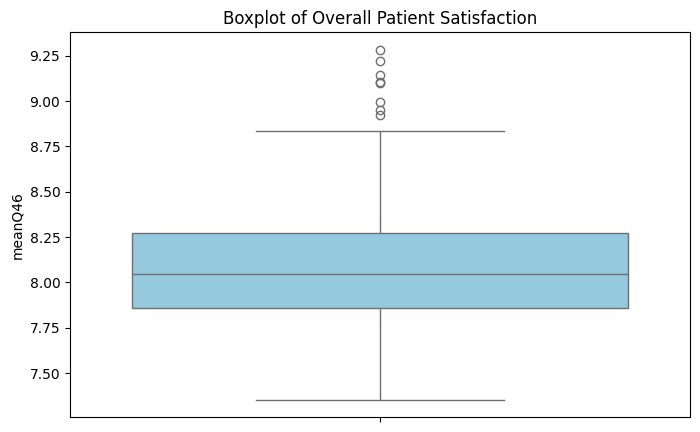

In [54]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df['meanQ46'],
            color='skyblue')

plt.title('Boxplot of Overall Patient Satisfaction')

plt.show()

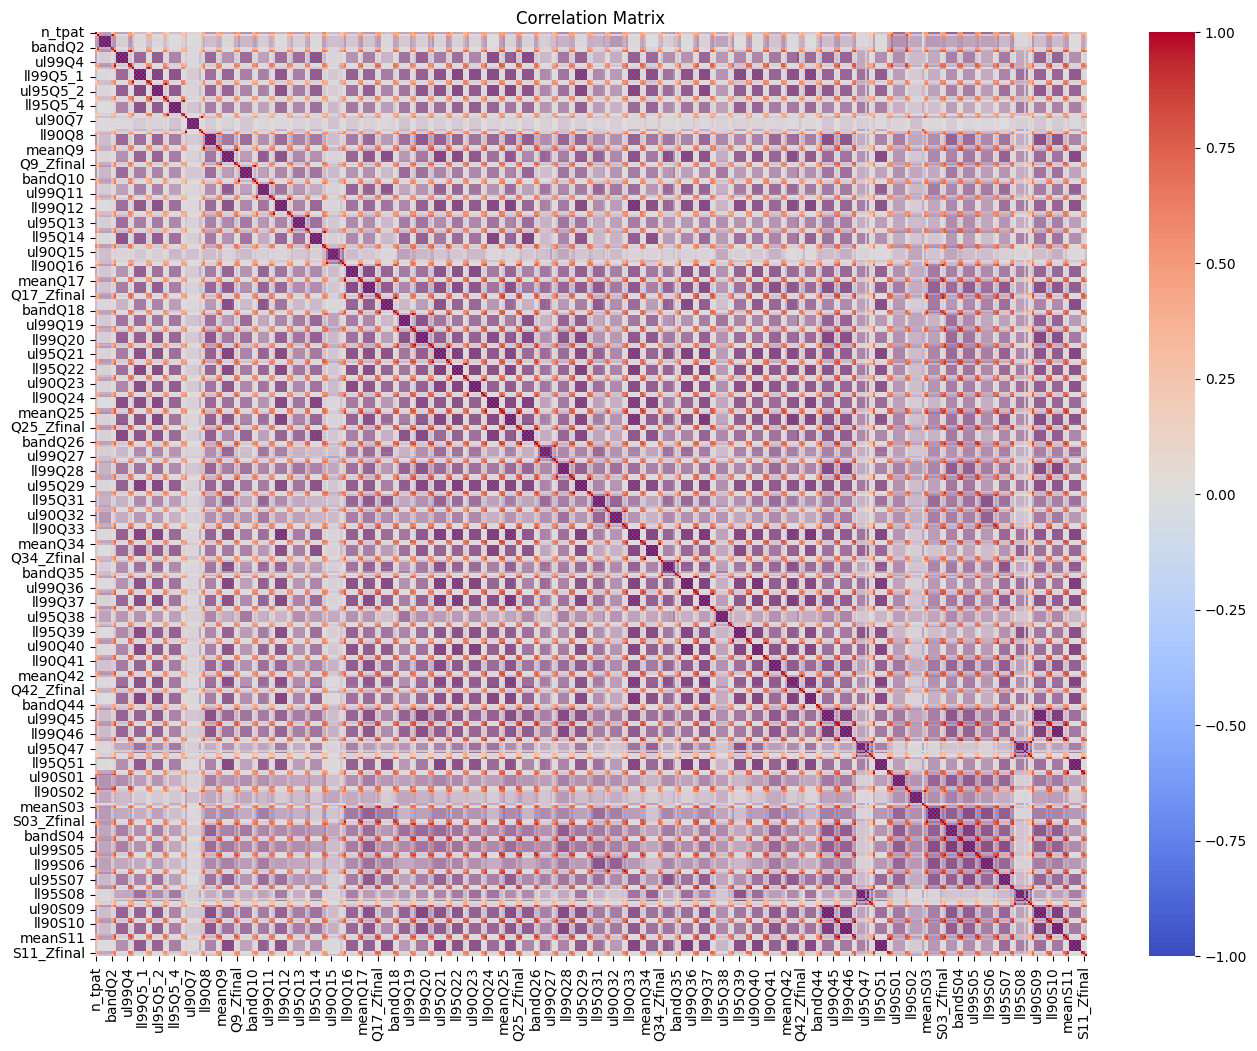

In [55]:
plt.figure(figsize=(16,12))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            cmap='coolwarm',
            annot=False)

plt.title("Correlation Matrix")

plt.show()

In [56]:
corr_target = corr['meanQ46'].sort_values(ascending=False)

print(corr_target.head(15))

meanQ46       1.000000
meanS10       1.000000
S10_Zfinal    0.998627
Q46_Zfinal    0.998627
S05_Zfinal    0.942979
meanS05       0.940442
Q45_Zfinal    0.919692
S09_Zfinal    0.919692
S04_Zfinal    0.911884
meanS04       0.907405
meanQ45       0.906114
meanS09       0.906114
S07_Zfinal    0.897787
meanQ24       0.897311
Q24_Zfinal    0.896504
Name: meanQ46, dtype: float64


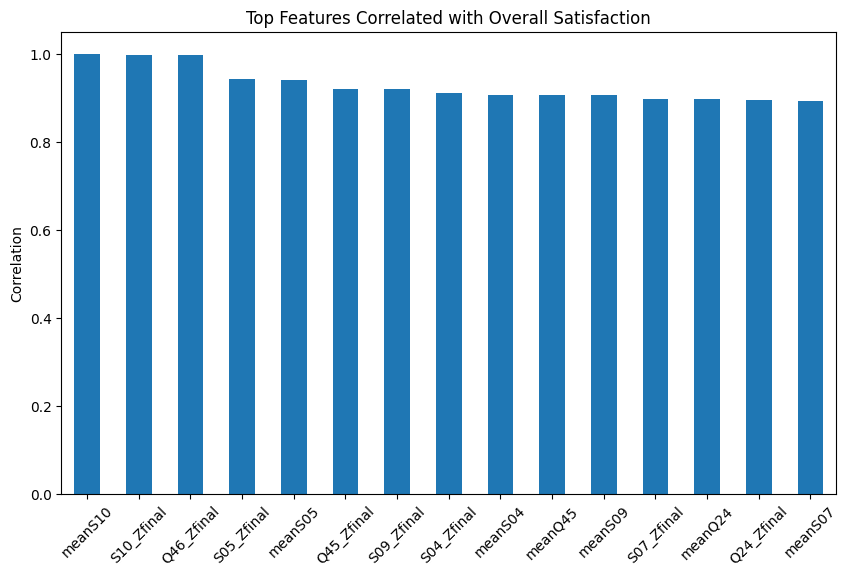

In [57]:
plt.figure(figsize=(10,6))

corr_target.iloc[1:16].plot(kind='bar')

plt.title("Top Features Correlated with Overall Satisfaction")

plt.ylabel("Correlation")

plt.xticks(rotation=45)

plt.show()

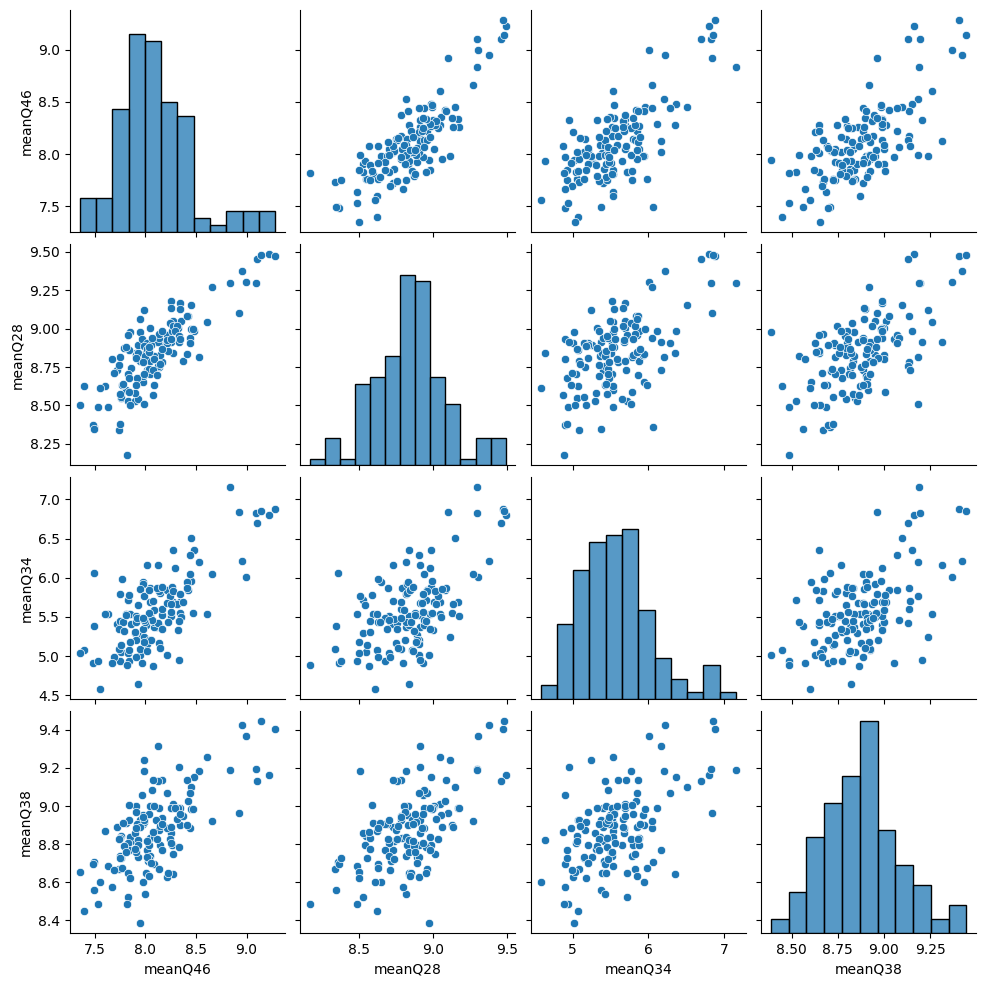

In [58]:
selected = [
    'meanQ46',
    'meanQ28',
    'meanQ34',
    'meanQ38'
]

sns.pairplot(df[selected])

plt.show()

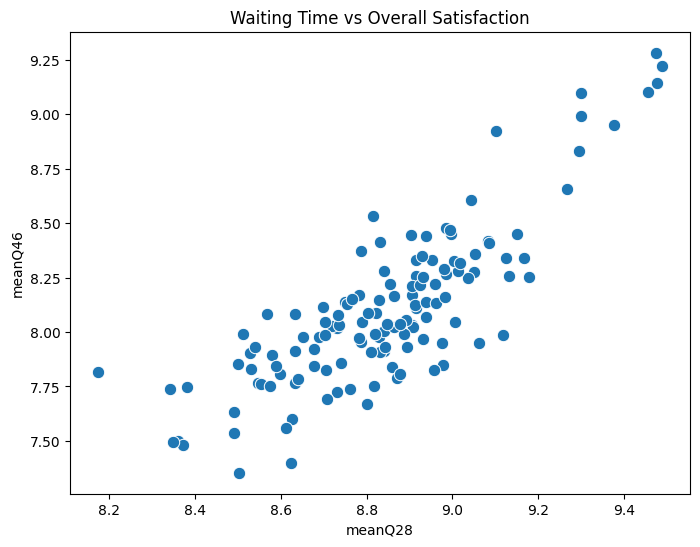

In [59]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='meanQ28',
    y='meanQ46',
    data=df,
    s=80
)

plt.title("Waiting Time vs Overall Satisfaction")

plt.show()

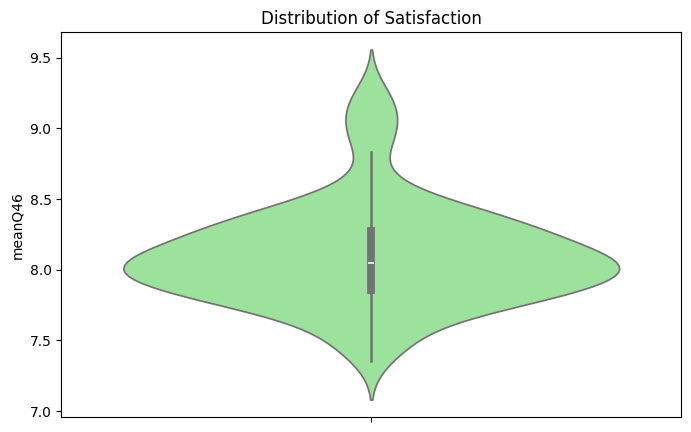

In [60]:
plt.figure(figsize=(8,5))

sns.violinplot(y=df['meanQ46'],
               color='lightgreen')

plt.title("Distribution of Satisfaction")

plt.show()

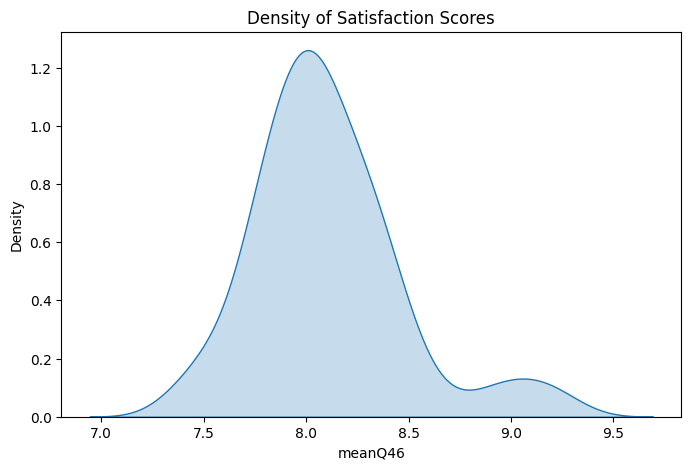

In [61]:
plt.figure(figsize=(8,5))

sns.kdeplot(df['meanQ46'],
            fill=True)

plt.title("Density of Satisfaction Scores")

plt.show()

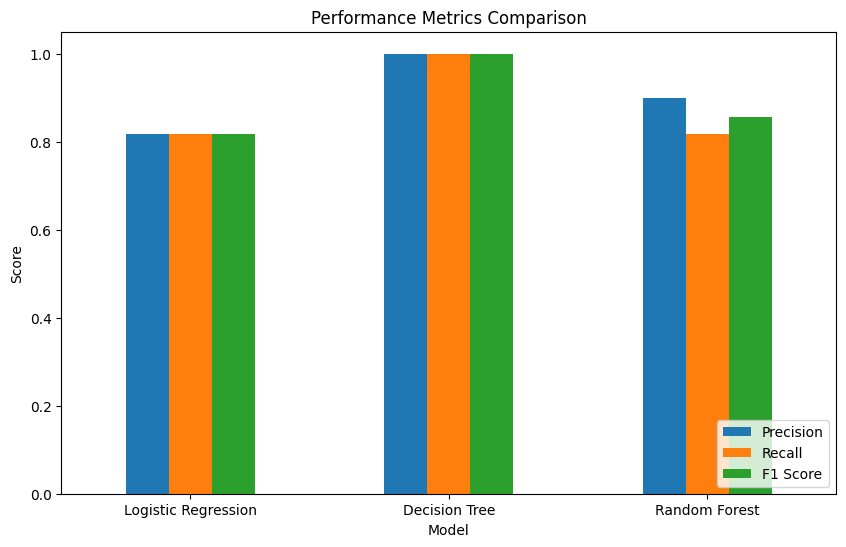

In [62]:
metrics = results.set_index('Model')[['Precision','Recall','F1 Score']]

metrics.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Performance Metrics Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.legend(loc='lower right')

plt.show()

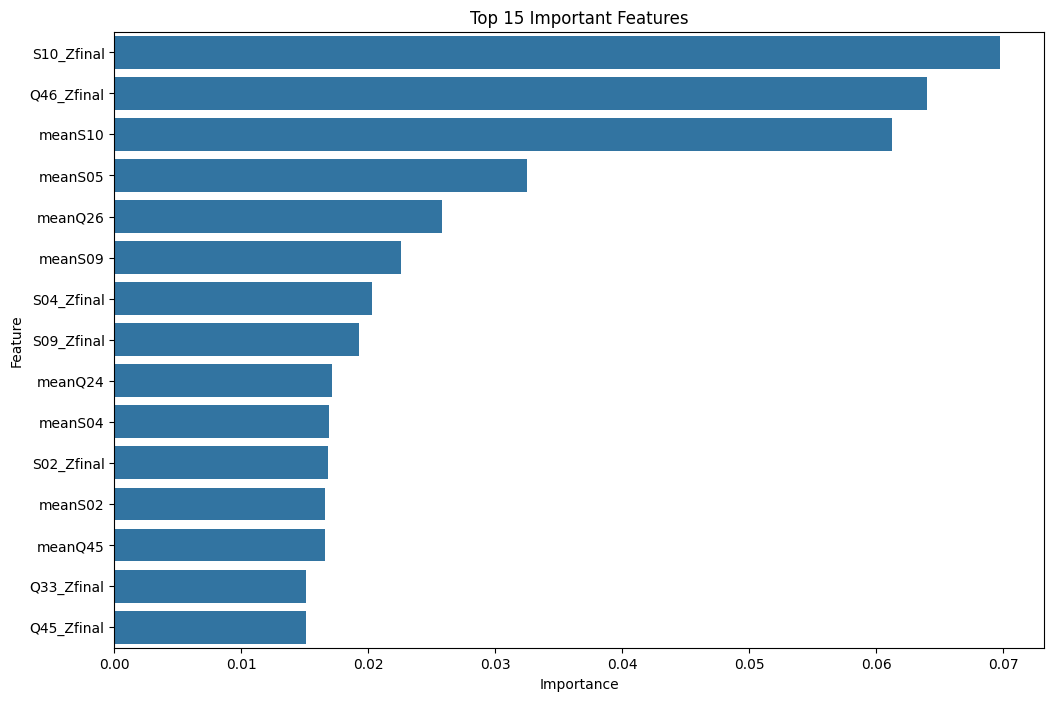

In [63]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Important Features")

plt.show()

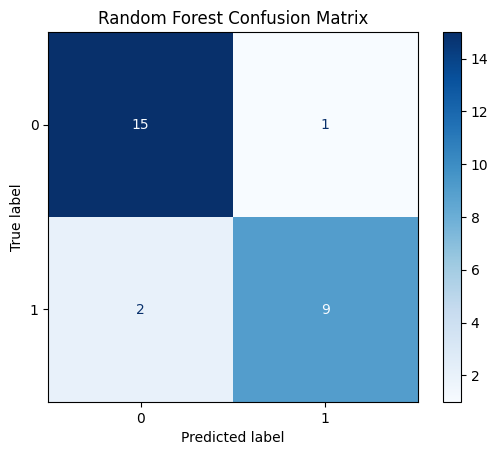

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.show()